# Problem 3 — PCA cannot, but ICA can, recover mixed sources

MATH70102 Unsupervised Learning

We construct three one-dimensional data sets $x_1,\dots,x_n$ (here written
$x_{1,i}, x_{2,i}, x_{3,i}$ for $i=1,\dots,n$) and observe only their linear
mixtures
$$
y_{j,i} \;=\; \sum_{k=1}^{3} a_{j,k}\, x_{k,i},\qquad j=1,2,3,
$$
i.e. $Y = A X$ for a fixed $3\times 3$ mixing matrix $A$. This is the classic
**cocktail-party problem**: three sources are heard through three microphones,
each of which records a different blend, and we wish to recover the sources from
the blends alone.

## Rationale for the construction

We must choose the sources $X$ and the matrix $A$ so that the contrast between
PCA and ICA is sharp. Two design choices do this.

**1. Non-Gaussian, independent sources.** The fundamental assumption behind ICA
(Week 4) is that the sources are *mutually statistically independent* and that
**at most one of them is Gaussian** — a rotation of independent Gaussians is again
independent Gaussian, so a purely Gaussian model is unidentifiable. We therefore
use three *distinctly non-Gaussian* structured signals — a **sine**, a **square**
wave and a **sawtooth** — generated on disjoint frequencies so they are
independent. Their sharply different shapes also let us *see* success or failure
directly in the plots.

**2. A non-orthogonal mixing matrix.** PCA (Week 2) only uses *second-order*
statistics: it finds **orthogonal directions of maximum variance**. Concretely it
decorrelates (whitens) the data, but after whitening any remaining *rotation*
leaves the covariance unchanged, so PCA has no way to undo it — it returns mutually
orthogonal components. If the true mixing matrix $A$ is **not** orthogonal, the
source directions are *not* orthogonal in observation space, so PCA's orthogonal
axes cannot line up with them and the principal components stay mixtures.

**ICA**, by contrast, ignores variance and instead maximises **statistical
independence / non-Gaussianity** (higher-order statistics). That extra criterion
pins down precisely the rotation PCA leaves undetermined, so ICA recovers the true
sources — up to the known caveats that the **order, sign and scale** of the
components are arbitrary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA, FastICA

plt.style.use("ggplot")
rng = np.random.default_rng(0)

## Step 1 — three independent non-Gaussian sources

We sample $n=2000$ points of a sine, a square and a sawtooth wave on different
frequencies, add a touch of noise, and standardise each source to zero mean and
unit variance (so that later normalisations are comparable).

In [2]:
n = 2000
t = np.linspace(0, 8, n)

x1 = np.sin(2 * t)                       # sine wave
x2 = np.sign(np.sin(3 * t))              # square wave
x3 = signal.sawtooth(2 * np.pi * t)      # sawtooth wave

X = np.vstack([x1, x2, x3])
X = X + 0.02 * rng.standard_normal(X.shape)   # small noise
X = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

names = [r"$x_1$ (sine)", r"$x_2$ (square)", r"$x_3$ (sawtooth)"]
colors = ["red", "blue", "purple"]
print("X shape:", X.shape)

X shape: (3, 2000)


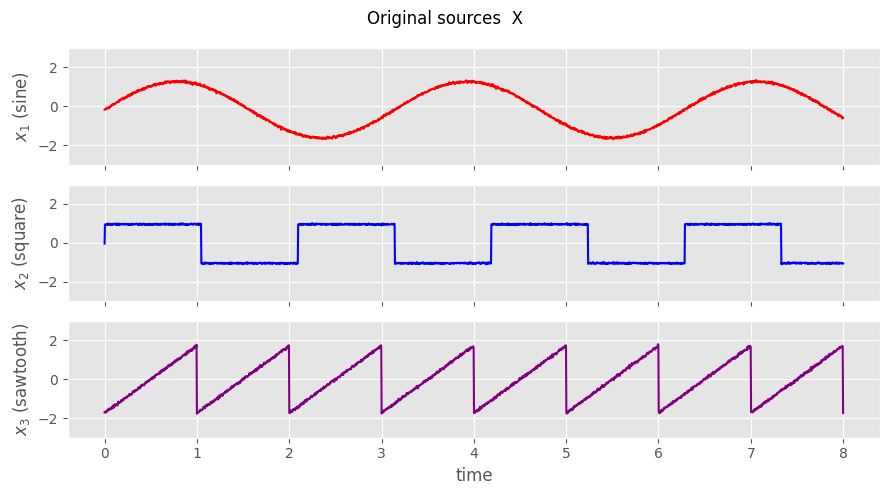

In [3]:
fig, axs = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for k in range(3):
    axs[k].plot(t, X[k], color=colors[k])
    axs[k].set_ylabel(names[k])
    axs[k].set_ylim(-3, 3)
axs[-1].set_xlabel("time")
fig.suptitle("Original sources  X")
plt.tight_layout()
plt.show()

The three sources have very different shapes and are mutually independent;
each is clearly non-Gaussian (the square wave is bimodal, the sawtooth is roughly
uniform, the sine is arcsine-shaped). This satisfies the ICA assumptions.

## Step 2 — mix the sources

We fix a deliberately **non-orthogonal**, invertible mixing matrix $A$ and form the
observed mixtures $Y = A X$. The mixtures are what the three "microphones" record.

In [4]:
A = np.array([
    [1.0, 1.0, 1.0],
    [0.5, 2.0, 1.0],
    [1.5, 1.0, 2.0],
])
print("rank(A) =", np.linalg.matrix_rank(A), " (3 => invertible)")
# How far A is from orthogonal: A A^T is far from a scaled identity.
print("A @ A.T =\n", A @ A.T)

Y = A @ X
print("Y shape:", Y.shape)

rank(A) = 3  (3 => invertible)
A @ A.T =
 [[3.   3.5  4.5 ]
 [3.5  5.25 4.75]
 [4.5  4.75 7.25]]
Y shape: (3, 2000)


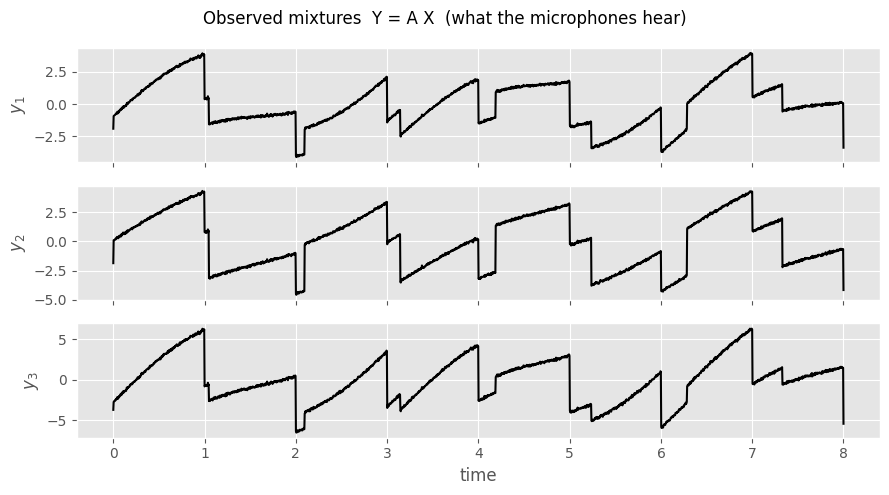

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for j in range(3):
    axs[j].plot(t, Y[j], color="black")
    axs[j].set_ylabel(rf"$y_{j+1}$")
axs[-1].set_xlabel("time")
fig.suptitle("Observed mixtures  Y = A X  (what the microphones hear)")
plt.tight_layout()
plt.show()

Each mixture is a scrambled blend of all three sources — the individual
sine, square and sawtooth shapes are no longer separable by eye.

## Step 3 — PCA on the mixtures

Following the Week 2 / lecture-notebook recipe, we apply `PCA` to the mixtures
(samples as rows, hence `Y.T`) and normalise each component by its maximum, since
component scale is not meaningful.

In [6]:
pca = PCA(n_components=3)
Z = pca.fit_transform(Y.T)
Z = Z / np.max(np.abs(Z), axis=0)   # normalise each PC
Z = Z.T                              # back to 3 x n
print("explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

explained variance ratio: [0.909 0.088 0.003]


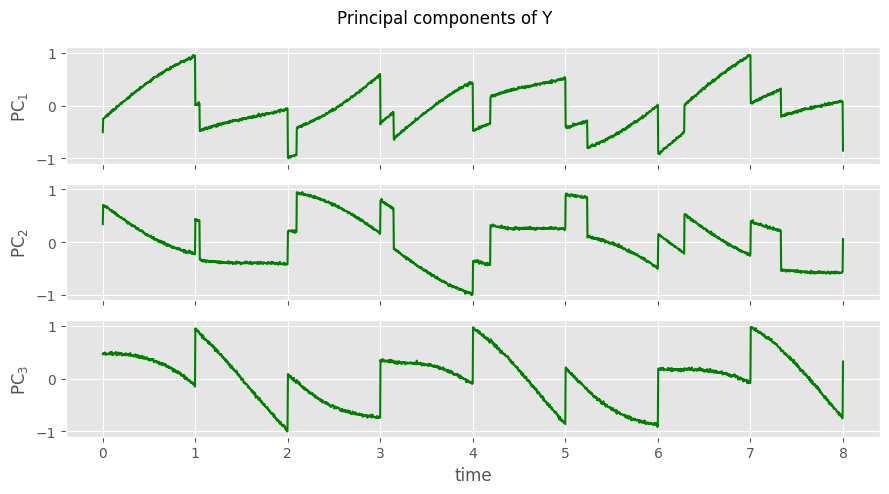

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for k in range(3):
    axs[k].plot(t, Z[k], color="green")
    axs[k].set_ylabel(rf"PC$_{k+1}$")
    axs[k].set_ylim(-1.1, 1.1)
axs[-1].set_xlabel("time")
fig.suptitle("Principal components of Y")
plt.tight_layout()
plt.show()

### PCA fails

The principal components still look like mixtures: none of them reproduces a clean
sine, square or sawtooth. We quantify this with the matrix of absolute correlations
between each principal component and each original source.

In [8]:
def corr_matrix(R, S):
    # |correlation| between rows of R (recovered) and rows of S (sources)
    M = np.zeros((R.shape[0], S.shape[0]))
    for i in range(R.shape[0]):
        for j in range(S.shape[0]):
            M[i, j] = np.abs(np.corrcoef(R[i], S[j])[0, 1])
    return M

C_pca = corr_matrix(Z, X)
print("|corr|  rows = PC1..3,  cols = x1,x2,x3")
print(np.round(C_pca, 3))
print("\nBest |corr| each PC achieves with any source:",
      np.round(C_pca.max(axis=1), 3))

|corr|  rows = PC1..3,  cols = x1,x2,x3
[[0.516 0.612 0.601]
 [0.407 0.782 0.437]
 [0.753 0.119 0.67 ]]

Best |corr| each PC achieves with any source: [0.612 0.782 0.753]


No principal component is strongly aligned with a single source — each row
mixes substantial correlation across several sources, and no clean one-to-one
matching exists. PCA's orthogonality constraint is the wrong criterion here,
because the true source directions (columns of $A$) are **not** orthogonal.

## Step 4 — ICA on the mixtures

Now we apply `FastICA`, the version of ICA seen in lectures, with the same
normalisation. ICA seeks components that are maximally **statistically independent**
/ non-Gaussian.

In [9]:
ica = FastICA(n_components=3, whiten="unit-variance", random_state=0, max_iter=1000)
S = ica.fit_transform(Y.T)
S = S / np.max(np.abs(S), axis=0)    # normalise each IC
S = S.T                               # back to 3 x n
print("S shape:", S.shape)

S shape: (3, 2000)


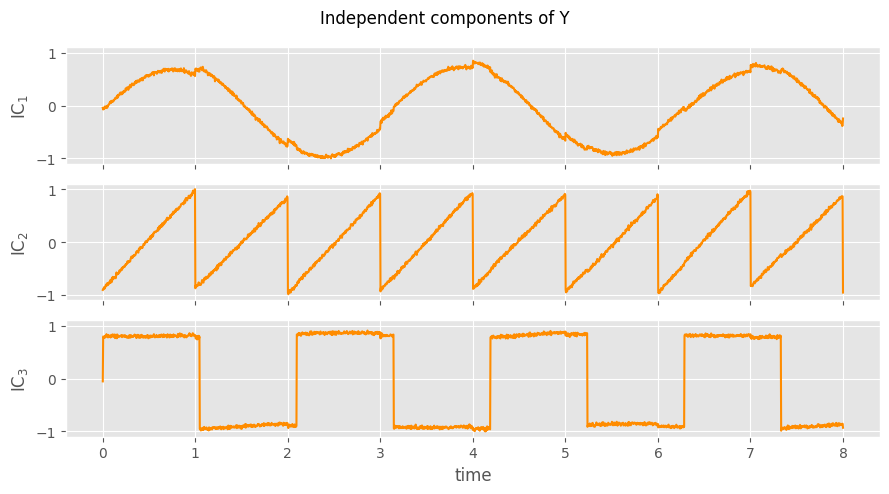

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for k in range(3):
    axs[k].plot(t, S[k], color="darkorange")
    axs[k].set_ylabel(rf"IC$_{k+1}$")
    axs[k].set_ylim(-1.1, 1.1)
axs[-1].set_xlabel("time")
fig.suptitle("Independent components of Y")
plt.tight_layout()
plt.show()

### ICA succeeds (up to order, sign and scale)

The independent components reproduce the sine, square and sawtooth shapes. To
compare with the originals we (i) match each IC to its best source via the
absolute-correlation matrix, and (ii) flip signs where needed — exactly the
permutation/sign/scale caveats of ICA.

In [11]:
C_ica = corr_matrix(S, X)
print("|corr|  rows = IC1..3,  cols = x1,x2,x3")
print(np.round(C_ica, 3))

# Optimal IC -> source assignment (maximise total |corr|).
row, col = linear_sum_assignment(-C_ica)
order = col[np.argsort(row)]            # source index matched to IC1, IC2, IC3
matched_corr = C_ica[np.arange(3), order]
print("\nIC k  ->  source index :", order)
print("matched |corr|         :", np.round(matched_corr, 4))
print("max recovery error 1-|corr|:", np.round(1 - matched_corr.min(), 4))

|corr|  rows = IC1..3,  cols = x1,x2,x3
[[0.997 0.03  0.069]
 [0.055 0.015 0.997]
 [0.058 0.999 0.037]]

IC k  ->  source index : [0 2 1]
matched |corr|         : [0.9968 0.9969 0.9994]
max recovery error 1-|corr|: 0.0032


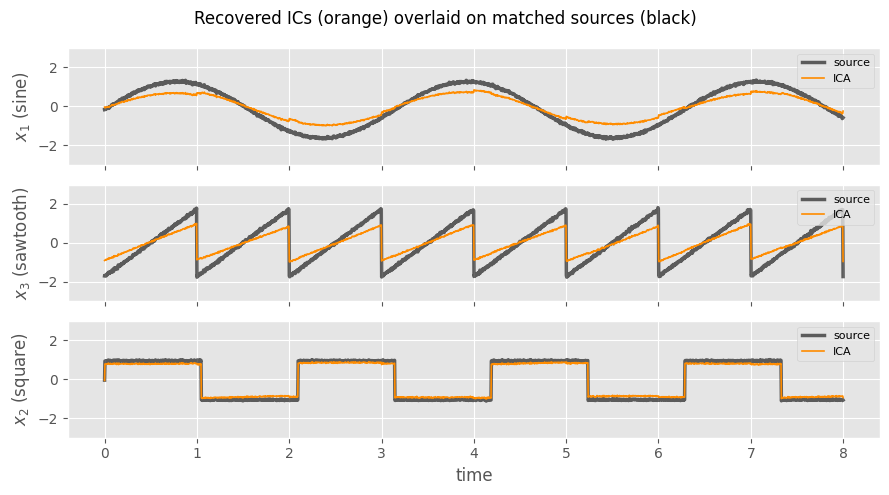

In [12]:
fig, axs = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for k in range(3):
    src = order[k]
    sign = np.sign(np.corrcoef(S[k], X[src])[0, 1])  # undo arbitrary sign
    axs[k].plot(t, X[src], color="black", lw=2.5, label="source", alpha=0.6)
    axs[k].plot(t, sign * S[k], color="darkorange", lw=1.2, label="ICA")
    axs[k].set_ylabel(names[src])
    axs[k].set_ylim(-3, 3)
    axs[k].legend(loc="upper right", fontsize=8)
axs[-1].set_xlabel("time")
fig.suptitle("Recovered ICs (orange) overlaid on matched sources (black)")
plt.tight_layout()
plt.show()

Each recovered component sits almost exactly on top of its source; the only
differences are the arbitrary ordering, an overall sign/scale, and tiny numerical
error — precisely the caveats stated in the question.

## Conclusion

| method | criterion | result |
|---|---|---|
| **PCA** | orthogonal directions of maximum variance (2nd-order) | components stay mixtures; no source recovered |
| **ICA** | statistical independence / non-Gaussianity (higher-order) | sources recovered up to order, sign, scale |

**Why PCA cannot recover the sources.** PCA can only decorrelate the mixtures and
returns mutually *orthogonal* components. Because the mixing matrix $A$ is **not**
orthogonal, the true source directions are not orthogonal either, so PCA's axes
cannot align with them — the principal components remain blends, as the low,
spread-out PCA correlation matrix confirms.

**Why ICA can.** After whitening, the sources differ from the principal axes only
by a rotation, and that rotation is invisible to second-order statistics. ICA fixes
it by demanding *independent*, maximally non-Gaussian components, which (because at
most one source is Gaussian) is enough to identify the sources. The recovered
components match the originals with $|\text{corr}|\approx 1$, confirming recovery
"up to reordering, scaling and some minor error".